In [ ]:
### CIFAR Data Exploration

In [1]:
# The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images.

In [122]:
import torchvision
import torchvision.transforms as transforms
import os
import pickle
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np


In [46]:
# torchvision.datasets.CIFAR10(root="./data1", train=True, download=True)  

In [47]:
### temp

In [48]:
# from torchvision import datasets, transforms

# transform = transforms.ToTensor()

# # Download CIFAR-10
# cifar10_train = datasets.CIFAR10(
#     root="./data",
#     train=True,
#     download=True,
#     transform=transform
# )

In [44]:
cifar10_train.data.shape  # (50000, 32, 32, 3) = 50000 images × 32×32 pixels × 3 color channels (RGB)


(50000, 32, 32, 3)

In [73]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# check the content

In [49]:
# fname = "data/cifar-10-batches-py/data_batch_1" # 
fname = "/Users/rdallatorre/repos/cifar-10/data/cifar-10-batches-py/data_batch_1"
with open(fname, "rb") as f:
    batch = pickle.load(f, encoding="bytes")

/var/folders/f3/6t3_glts4f750tgbc37vpgxm0000gn/T/ipykernel_16081/2526300736.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  batch = pickle.load(f, encoding="bytes")


In [50]:
batch.keys()

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])

In [58]:
print(type(batch))
print(batch.keys())
print(batch[b'data'].shape, batch[b'data'].dtype)
print(len(batch[b'labels']))
print(set(batch[b'labels']))  # should be 0–9

<class 'dict'>
dict_keys([b'batch_label', b'labels', b'data', b'filenames'])
(10000, 3072) uint8
10000
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}


In [51]:
print(f"Images shape: {batch[b'data'].shape}")   # (10000, 3072) = 10000 images × 32×32×3. #RGB
print(f"Labels: {batch[b'labels'][:10]}")         # first 10 labels

Images shape: (10000, 3072)
Labels: [6, 9, 9, 4, 1, 1, 2, 7, 8, 3]


In [69]:
#[ R×1024 | G×1024 | B×1024 ]

In [71]:
# dimensions 32x32x3 = 3072

img = batch[b'data'][0]  # first image (flattened)
img = img.reshape(3,32,32)
img = img.transpose(1,2,0)  # convert from (C,H,W) to (H,W,C) for imshow

img.shape


(32, 32, 3)

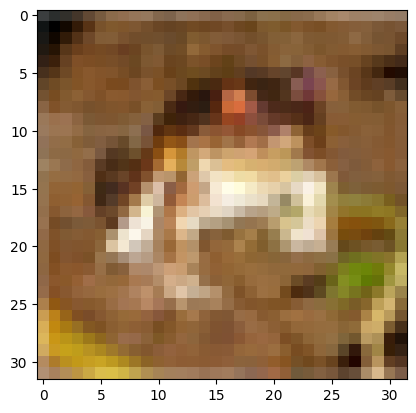

In [72]:
plt.imshow(img)  # show first image (flattened)


In [77]:
class_names[batch[b'labels'][0]]

'frog'

# read the data set using torchvision

In [32]:
print(os.listdir("data/"))


FileNotFoundError: [Errno 2] No such file or directory: 'data/'

In [ ]:
# torchvision knows the folder structure automatically
dataset = torchvision.datasets.CIFAR10(
    root = "/Users/rdallatorre/repos/cifar-10/data/",

    #root="/Users/rdallatorre/repos/cifar-10/data",       # just point to data/ — it finds cifar-10-batches-py/
    train=True,
    download=False,
    transform=transforms.ToTensor()
)


# ToTensor()
# Shape: (H,W,C) → (C,H,W) — channels first, PyTorch convention
# Values: uint8 [0-255] → float32 [0.0-1.0]

/Users/rdallatorre/repos/cifar-10/venv/lib/python3.11/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


The key attributes for CIFAR10 specifically:

dataset.data — numpy array (50000, 32, 32, 3)

dataset.targets — list of 50000 ints

dataset.classes — the class name list (you don't even need to define class_names manually!)

In [88]:
dataset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: /Users/rdallatorre/repos/cifar-10/data/
    Split: Train
    StandardTransform
Transform: ToTensor()

In [ ]:
labels = dataset.targets # list
cnt = Counter(labels)
cnt.values()

dict_values([5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000, 5000])

In [ ]:
plt.bar(dataset.classes,cnt.values())

In [126]:
image,label = dataset[0]


In [106]:
print(image.shape)
print(label)
print(class_names[label])

torch.Size([3, 32, 32])
6
frog


/var/folders/f3/6t3_glts4f750tgbc37vpgxm0000gn/T/ipykernel_16081/429937501.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image_ = np.array(image.permute(1,2,0))


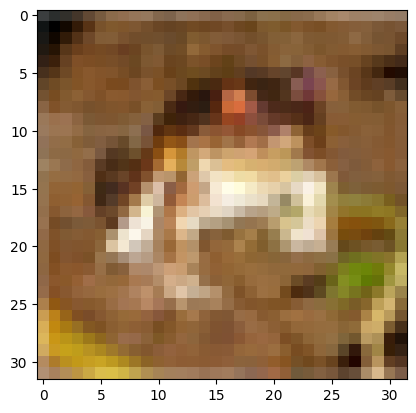

In [136]:
#image_ = np.array(image.reshape(32,32,3)) # (C,H,W) to (H,W,C)

image_ = np.array(image.permute(1,2,0))
plt.imshow(image_)

In [154]:
labels_ = np.array(labels)

idx

(array([    4,     5,    32, ..., 49993, 49998, 49999], shape=(5000,)),)

In [157]:
idx[0]

array([    4,     5,    32, ..., 49993, 49998, 49999], shape=(5000,))

/var/folders/f3/6t3_glts4f750tgbc37vpgxm0000gn/T/ipykernel_16081/2130515586.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image_ = np.array(image.permute(1,2,0))


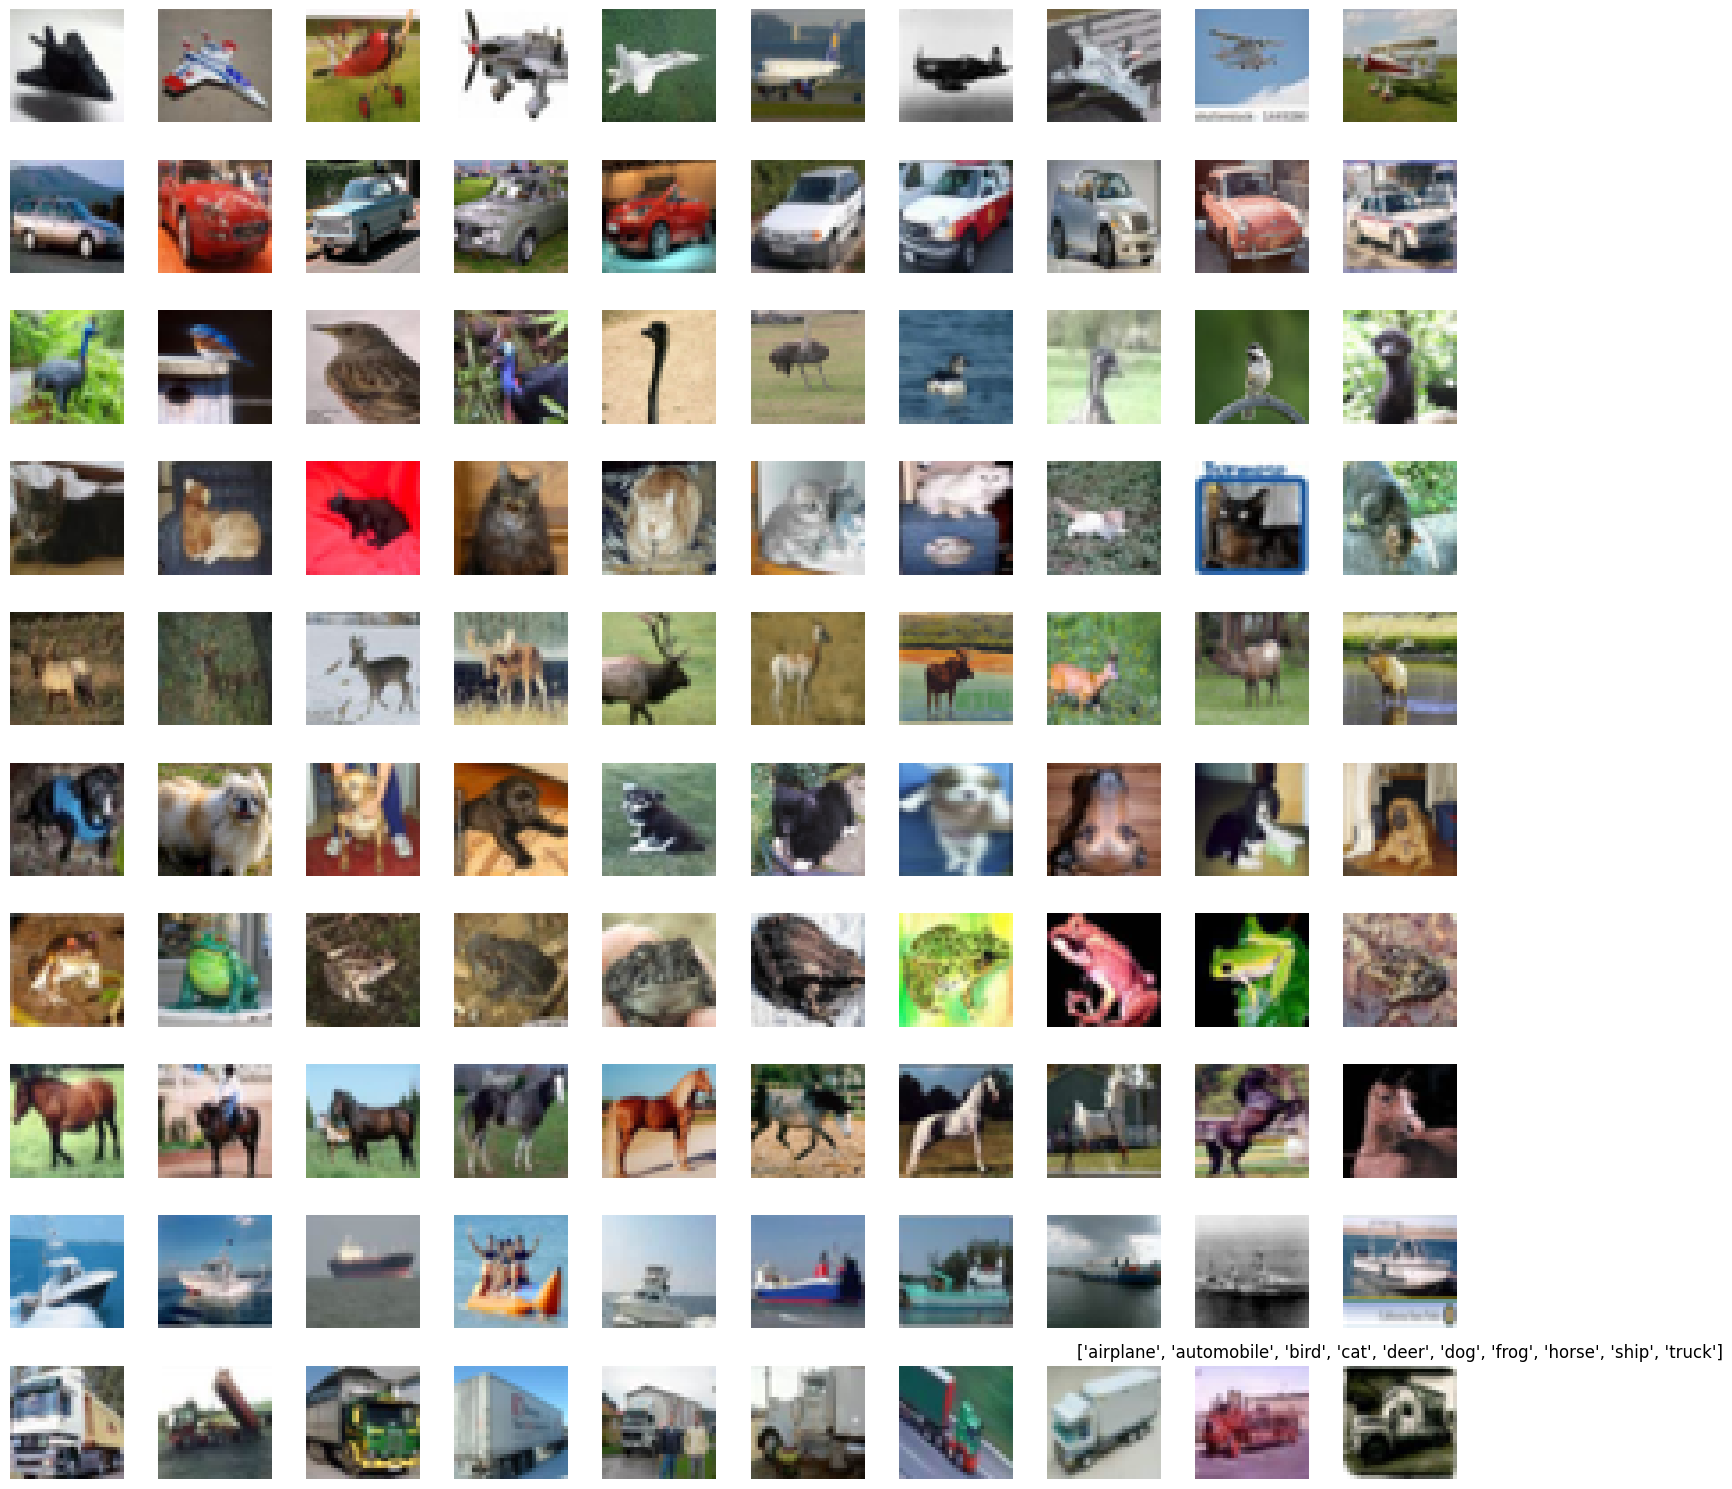

In [174]:
N = 10 # number of classes
M = 10 # examples
plt.figure(figsize=(M*1.5, N*1.5))
plt.subplots_adjust(left=0.1)

for class_idx in range(N):
    idx_class = np.where(labels_==class_idx)[0]
    for img_idx in range(M):
        idx = idx_class[img_idx]
        image, label = dataset[idx]
        image_ = np.array(image.permute(1,2,0))
        plt.subplot(N,M,class_idx*M+img_idx+1)
        plt.imshow(image_)
        plt.axis('off')
        if img_idx == 0:
            plt.ylabel(dataset.classes[class_idx], fontsize=8, rotation=0, labelpad=50)
plt.title(dataset.classes)
plt.tight_layout()
plt.show()



In [171]:
dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Classic CIFAR-10 confusions:

cat ↔ dog — similar body shape, fur texture, same scale

deer ↔ horse — four legs, similar body proportions, often similar backgrounds

automobile ↔ truck — both vehicles, similar colors and shapes

bird ↔ airplane — both appear small against sky backgrounds

# pixel statistics

In [187]:
# will be used for normalization....

In [183]:
np.mean(dataset.data,axis=(0,1,2))

array([125.30691805, 122.95039414, 113.86538318])

In [185]:
np.mean(dataset.data,axis=(0,1,2))/256

array([0.48948015, 0.48027498, 0.44478665])

In [186]:
np.std(dataset.data,axis=(0,1,2))/256

array([0.24606726, 0.24253401, 0.26056601])